# Linear Models Demo

This notebook demonstrates all linear models in mlengine.

In [7]:
import sys
import os

# Menambahkan folder utama ke daftar pencarian Python
sys.path.append(os.path.abspath("..")) 

import mlengine as mle
print(mle.__version__)

0.1.0


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression, make_classification
from sklearn.model_selection import train_test_split

import mlengine as mle
from mlengine.preprocessing import StandardScaler
from mlengine.evaluation import r2_score, accuracy_score, roc_auc_score, cross_val_score

print('mlengine version:', mle.__version__)

mlengine version: 0.1.0


## 1. Linear Regression (Normal Equation vs Gradient Descent)

In [9]:
X, y = make_regression(n_samples=500, n_features=10, noise=0.5, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

sc = StandardScaler()
X_tr_s = sc.fit_transform(X_tr)
X_te_s = sc.transform(X_te)

for method in ['normal', 'gd']:
    m = mle.LinearRegression(method=method, lr=0.05, n_iter=1000)
    m.fit(X_tr_s, y_tr)
    print(f'LinearRegression(method={method!r}): R²={m.score(X_te_s, y_te):.4f}')

LinearRegression(method='normal'): R²=1.0000
LinearRegression(method='gd'): R²=1.0000


## 2. Ridge vs Lasso Regularisation Path

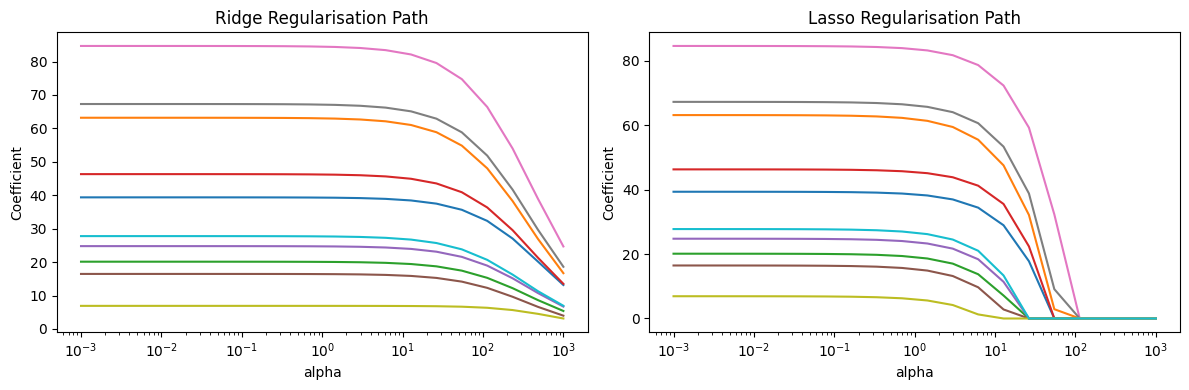

Lasso zeros at alpha=1.0: 0


In [10]:
alphas = np.logspace(-3, 3, 20)
ridge_coefs, lasso_coefs = [], []

for alpha in alphas:
    ridge_coefs.append(mle.RidgeRegression(alpha=alpha).fit(X_tr_s, y_tr).coef_)
    lasso_coefs.append(mle.LassoRegression(alpha=alpha, n_iter=2000).fit(X_tr_s, y_tr).coef_)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for coefs, ax, title in zip([ridge_coefs, lasso_coefs], axes, ['Ridge', 'Lasso']):
    for j in range(X_tr_s.shape[1]):
        ax.semilogx(alphas, [c[j] for c in coefs])
    ax.set_xlabel('alpha'); ax.set_ylabel('Coefficient'); ax.set_title(f'{title} Regularisation Path')
plt.tight_layout(); plt.show()
print('Lasso zeros at alpha=1.0:', np.sum(mle.LassoRegression(alpha=1.0).fit(X_tr_s, y_tr).coef_ == 0))

## 3. Logistic Regression with Cross-Validation

In [11]:
X_c, y_c = make_classification(n_samples=1000, n_features=20, n_informative=10, random_state=42)

pipe = mle.make_pipeline(
    StandardScaler(),
    mle.LogisticRegression(C=1.0, n_iter=500),
)
scores = cross_val_score(pipe, X_c, y_c, cv=5, scoring='accuracy')
print(f'5-fold CV: {scores.mean():.3f} ± {scores.std():.3f}')

# Grid search
grid = mle.GridSearchCV(
    mle.LogisticRegression(n_iter=300),
    param_grid={'C': [0.01, 0.1, 1.0, 10.0]},
    cv=3,
)
sc2 = StandardScaler()
Xs = sc2.fit_transform(X_c)
grid.fit(Xs, y_c)
print(f'Best C: {grid.best_params_["C"]}, Score: {grid.best_score_:.3f}')

5-fold CV: 0.812 ± 0.026
Best C: 10.0, Score: 0.842


## 4. Multiclass Logistic Regression

In [12]:
from sklearn.datasets import load_iris
iris = load_iris()
X_i, y_i = iris.data, iris.target

pipe_iris = mle.make_pipeline(
    StandardScaler(),
    mle.LogisticRegression(multi_class='softmax', n_iter=500, C=5.0),
)
scores_iris = cross_val_score(pipe_iris, X_i, y_i, cv=5)
print(f'Iris (softmax) 5-fold CV: {scores_iris.mean():.3f} ± {scores_iris.std():.3f}')

Iris (softmax) 5-fold CV: 0.860 ± 0.065
